In [1]:
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
model_name = "sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2"

model = SentenceTransformer(model_name)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

In [3]:
sentence = "我正在学习机器学习和人工智能。"

embedding = model.encode(sentence)

print(type(embedding))
print(embedding.shape)
print(embedding[:10])

<class 'numpy.ndarray'>
(384,)
[ 0.07417677 -0.14830926 -0.04596844 -0.14115801 -0.02236806  0.01898725
 -0.00275292 -0.11695216  0.07429377  0.14681247]


In [4]:
sentences = [
    "我喜欢机器学习。",
    "我正在学习人工智能。",
    "今天广州天气很好。",
    "深度学习是机器学习的一个重要方向。",
    "我晚上想去吃火锅。"
]

embeddings = model.encode(sentences)

print(type(embeddings))
print(embeddings.shape)

<class 'numpy.ndarray'>
(5, 384)


In [5]:
df = pd.DataFrame(embeddings)

df.head()

,0,1,2,3,4,5,6,7,8,9,...,374,375,376,377,378,379,380,381,382,383
0,0.012228,-0.175325,-0.090056,-0.221283,-0.191102,-0.051048,-0.023247,0.117260,0.003428,0.157484,...,0.658787,0.316809,0.042453,-0.291794,0.113872,0.277906,0.085077,0.034764,-0.076375,-0.434688
1,0.109889,-0.265529,-0.110197,-0.163050,-0.036721,-0.017096,0.326495,-0.090288,0.206279,0.343825,...,0.651768,0.242648,0.405682,-0.150857,-0.175860,0.356103,0.091656,0.037138,-0.049919,-0.504879
2,0.131289,-0.008630,0.018308,0.380552,0.053771,0.093083,0.357113,0.129171,-0.389599,0.270465,...,-0.216100,-0.277779,0.148781,-0.020202,0.501855,-0.326613,0.284934,0.295289,-0.468332,0.553473
3,-0.158247,0.095182,0.029604,-0.122577,-0.077343,0.127385,-0.254496,-0.187500,-0.001136,-0.317845,...,0.326018,0.278319,-0.074449,-0.145668,-0.000577,0.313919,-0.326239,-0.019191,-0.315291,-0.185252
4,0.380527,0.128634,0.038826,0.323712,-0.140878,0.047649,0.002856,-0.385079,-0.101283,-0.060589,...,0.214831,-0.029497,0.231918,-0.046686,0.162743,-0.226349,0.154645,0.196037,-0.184980,-0.372515


In [6]:
s1 = "我喜欢机器学习。"
s2 = "我对人工智能很感兴趣。"

emb1 = model.encode([s1])
emb2 = model.encode([s2])

sim = cosine_similarity(emb1, emb2)

print(sim)

[[0.55300176]]


In [7]:
s1 = "我喜欢机器学习。"
s2 = "今天晚上我想吃火锅。"

emb1 = model.encode([s1])
emb2 = model.encode([s2])

sim = cosine_similarity(emb1, emb2)

print(sim)

[[0.19753543]]


In [8]:
def sentence_similarity(text1, text2):
    emb1 = model.encode([text1])
    emb2 = model.encode([text2])
    
    sim = cosine_similarity(emb1, emb2)[0][0]
    
    return sim

In [9]:
pairs = [
    ("我喜欢机器学习。", "我正在学习人工智能。"),
    ("我喜欢机器学习。", "深度学习是机器学习的一个方向。"),
    ("我喜欢机器学习。", "今天广州下雨了。"),
    ("我晚上想吃火锅。", "我想去吃麻辣烫。"),
    ("AI Agent 可以调用工具。", "智能体可以使用外部工具完成任务。")
]

for a, b in pairs:
    score = sentence_similarity(a, b)
    print(f"句子1：{a}")
    print(f"句子2：{b}")
    print(f"相似度：{score:.4f}")
    print("-" * 50)

句子1：我喜欢机器学习。
句子2：我正在学习人工智能。
相似度：0.5592
--------------------------------------------------
句子1：我喜欢机器学习。
句子2：深度学习是机器学习的一个方向。
相似度：0.5784
--------------------------------------------------
句子1：我喜欢机器学习。
句子2：今天广州下雨了。
相似度：-0.0254
--------------------------------------------------
句子1：我晚上想吃火锅。
句子2：我想去吃麻辣烫。
相似度：0.6170
--------------------------------------------------
句子1：AI Agent 可以调用工具。
句子2：智能体可以使用外部工具完成任务。
相似度：0.6616
--------------------------------------------------


In [10]:
sentences = [
    "我喜欢机器学习。",
    "我正在学习人工智能。",
    "深度学习是机器学习的重要方向。",
    "今天广州天气很好。",
    "我晚上想去吃火锅。",
    "AI Agent 可以调用工具完成任务。"
]

embeddings = model.encode(sentences)

similarity_matrix = cosine_similarity(embeddings)

similarity_matrix

array([[ 1.0000001 ,  0.5591544 ,  0.584883  ,  0.08349352,  0.22407691,
         0.30466208],
       [ 0.5591544 ,  1.        ,  0.39687362, -0.01814363,  0.0988606 ,
         0.6810869 ],
       [ 0.584883  ,  0.39687362,  0.99999976, -0.06740669,  0.07070227,
         0.25914714],
       [ 0.08349352, -0.01814363, -0.06740669,  1.0000002 ,  0.14775103,
        -0.09742391],
       [ 0.22407691,  0.0988606 ,  0.07070227,  0.14775103,  0.9999999 ,
        -0.01763462],
       [ 0.30466208,  0.6810869 ,  0.25914714, -0.09742391, -0.01763462,
         1.0000002 ]], dtype=float32)

In [11]:
sim_df = pd.DataFrame(
    similarity_matrix,
    index=sentences,
    columns=sentences
)

sim_df

,我喜欢机器学习。,我正在学习人工智能。,深度学习是机器学习的重要方向。,今天广州天气很好。,我晚上想去吃火锅。,AI Agent 可以调用工具完成任务。
我喜欢机器学习。,1.000000,0.559154,0.584883,0.083494,0.224077,0.304662
我正在学习人工智能。,0.559154,1.000000,0.396874,-0.018144,0.098861,0.681087
深度学习是机器学习的重要方向。,0.584883,0.396874,1.000000,-0.067407,0.070702,0.259147
今天广州天气很好。,0.083494,-0.018144,-0.067407,1.000000,0.147751,-0.097424
我晚上想去吃火锅。,0.224077,0.098861,0.070702,0.147751,1.000000,-0.017635
AI Agent 可以调用工具完成任务。,0.304662,0.681087,0.259147,-0.097424,-0.017635,1.000000


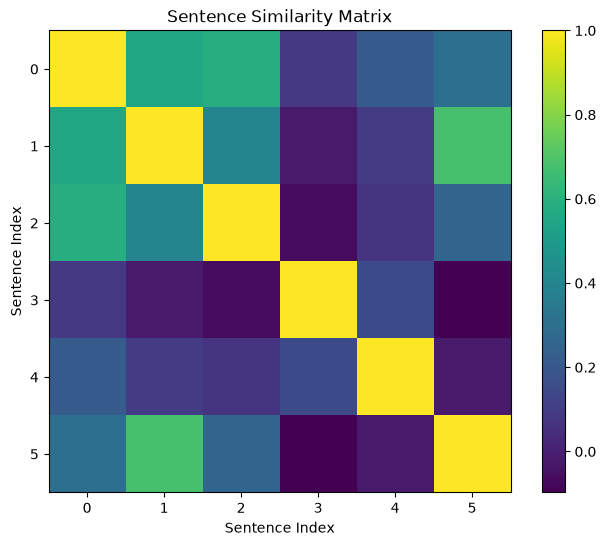

In [12]:
plt.figure(figsize=(8, 6))

plt.imshow(similarity_matrix)
plt.colorbar()

plt.xticks(range(len(sentences)), range(len(sentences)))
plt.yticks(range(len(sentences)), range(len(sentences)))

plt.title("Sentence Similarity Matrix")
plt.xlabel("Sentence Index")
plt.ylabel("Sentence Index")

plt.show()

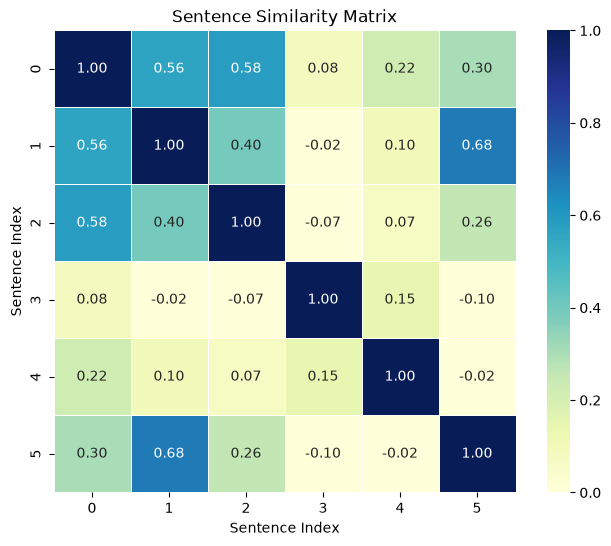

In [29]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

sns.heatmap(
    similarity_matrix,
    annot=True,
    fmt=".2f",
    cmap="YlGnBu",
    vmin=0,
    vmax=1,
    square=True,
    linewidths=0.5
)

plt.title("Sentence Similarity Matrix")
plt.xlabel("Sentence Index")
plt.ylabel("Sentence Index")

plt.show()

In [13]:
for i, s in enumerate(sentences):
    print(i, s)

0 我喜欢机器学习。
1 我正在学习人工智能。
2 深度学习是机器学习的重要方向。
3 今天广州天气很好。
4 我晚上想去吃火锅。
5 AI Agent 可以调用工具完成任务。


In [14]:
documents = [
    "机器学习是一种让计算机从数据中学习规律的方法。",
    "深度学习是机器学习的一个分支，常用于图像识别和自然语言处理。",
    "广州是广东省省会，有很多大学和科技企业。",
    "AI Agent 可以通过调用工具、规划步骤和记忆信息来完成复杂任务。",
    "RAG 是一种结合检索和生成的技术，可以让大模型使用外部知识库。",
    "火锅是一种很受欢迎的聚餐食物。"
]

In [15]:
query = "什么是 RAG？"

In [16]:
doc_embeddings = model.encode(documents)
query_embedding = model.encode([query])

In [17]:
scores = cosine_similarity(query_embedding, doc_embeddings)[0]

scores

array([0.12398547, 0.12854679, 0.10347683, 0.04214726, 0.6132495 ,
       0.10574567], dtype=float32)

In [18]:
sorted_indices = np.argsort(scores)[::-1]

for idx in sorted_indices:
    print("相似度：", round(scores[idx], 4))
    print("文档：", documents[idx])
    print("-" * 50)

相似度： 0.6132
文档： RAG 是一种结合检索和生成的技术，可以让大模型使用外部知识库。
--------------------------------------------------
相似度： 0.1285
文档： 深度学习是机器学习的一个分支，常用于图像识别和自然语言处理。
--------------------------------------------------
相似度： 0.124
文档： 机器学习是一种让计算机从数据中学习规律的方法。
--------------------------------------------------
相似度： 0.1057
文档： 火锅是一种很受欢迎的聚餐食物。
--------------------------------------------------
相似度： 0.1035
文档： 广州是广东省省会，有很多大学和科技企业。
--------------------------------------------------
相似度： 0.0421
文档： AI Agent 可以通过调用工具、规划步骤和记忆信息来完成复杂任务。
--------------------------------------------------


In [19]:
def semantic_search(query, documents, top_k=3):
    doc_embeddings = model.encode(documents)
    query_embedding = model.encode([query])
    
    scores = cosine_similarity(query_embedding, doc_embeddings)[0]
    sorted_indices = np.argsort(scores)[::-1]
    
    results = []
    
    for idx in sorted_indices[:top_k]:
        results.append({
            "document": documents[idx],
            "score": scores[idx]
        })
    
    return results

In [20]:
query = "智能体怎么完成任务？"

results = semantic_search(query, documents, top_k=3)

for r in results:
    print("相似度：", round(r["score"], 4))
    print("文档：", r["document"])
    print("-" * 50)

相似度： 0.6421
文档： AI Agent 可以通过调用工具、规划步骤和记忆信息来完成复杂任务。
--------------------------------------------------
相似度： 0.3121
文档： RAG 是一种结合检索和生成的技术，可以让大模型使用外部知识库。
--------------------------------------------------
相似度： 0.3006
文档： 机器学习是一种让计算机从数据中学习规律的方法。
--------------------------------------------------


In [21]:
knowledge_base = [
    "机器学习关注如何让计算机从数据中学习规律，并对未知样本进行预测。",
    "监督学习需要带标签的数据，例如分类任务和回归任务。",
    "无监督学习不需要标签，常见任务包括聚类和降维。",
    "Transformer 使用自注意力机制建模序列中不同位置之间的关系。",
    "BERT 是一种基于 Transformer Encoder 的预训练语言模型。",
    "GPT 是一种基于 Transformer Decoder 的生成式语言模型。",
    "Prompt Engineering 是设计提示词来引导大模型输出的技术。",
    "RAG 通过检索外部知识库增强大模型回答能力。",
    "AI Agent 可以感知环境、规划任务、调用工具并根据反馈调整行为。"
]

In [22]:
def search_knowledge_base(query, knowledge_base, top_k=3):
    kb_embeddings = model.encode(knowledge_base)
    query_embedding = model.encode([query])
    
    scores = cosine_similarity(query_embedding, kb_embeddings)[0]
    sorted_indices = np.argsort(scores)[::-1]
    
    print("用户问题：", query)
    print("=" * 60)
    
    for rank, idx in enumerate(sorted_indices[:top_k], start=1):
        print(f"Top {rank}")
        print("相似度：", round(scores[idx], 4))
        print("内容：", knowledge_base[idx])
        print("-" * 60)

In [23]:
search_knowledge_base("BERT 是什么模型？", knowledge_base)

用户问题： BERT 是什么模型？
Top 1
相似度： 0.4945
内容： BERT 是一种基于 Transformer Encoder 的预训练语言模型。
------------------------------------------------------------
Top 2
相似度： 0.3281
内容： Prompt Engineering 是设计提示词来引导大模型输出的技术。
------------------------------------------------------------
Top 3
相似度： 0.2548
内容： AI Agent 可以感知环境、规划任务、调用工具并根据反馈调整行为。
------------------------------------------------------------


In [24]:
search_knowledge_base("智能体如何调用工具完成任务？", knowledge_base)

用户问题： 智能体如何调用工具完成任务？
Top 1
相似度： 0.5514
内容： AI Agent 可以感知环境、规划任务、调用工具并根据反馈调整行为。
------------------------------------------------------------
Top 2
相似度： 0.469
内容： 监督学习需要带标签的数据，例如分类任务和回归任务。
------------------------------------------------------------
Top 3
相似度： 0.3884
内容： 机器学习关注如何让计算机从数据中学习规律，并对未知样本进行预测。
------------------------------------------------------------


In [25]:
search_knowledge_base("如何让大模型使用外部知识？", knowledge_base)

用户问题： 如何让大模型使用外部知识？
Top 1
相似度： 0.6513
内容： RAG 通过检索外部知识库增强大模型回答能力。
------------------------------------------------------------
Top 2
相似度： 0.5221
内容： 机器学习关注如何让计算机从数据中学习规律，并对未知样本进行预测。
------------------------------------------------------------
Top 3
相似度： 0.3883
内容： AI Agent 可以感知环境、规划任务、调用工具并根据反馈调整行为。
------------------------------------------------------------
